# neuro-deg-scanner — Example: Multiple Sclerosis (GSE26927)

This notebook shows how to run the full pipeline on an MS dataset in a few lines.

In [1]:
# Install if needed
import sys
!{sys.executable} -m pip install -q GEOparse scipy scikit-learn statsmodels seaborn adjustText


  neuro-deg-scanner  ·  GSE26927  ·  MS

[1/5] Fetching GSE26927 from NCBI GEO...
      Title   : Common neuroinflammatory pathways in neurodegenerative diseases.
      Samples : 118
[2/5] Building expression matrix...
      Matrix  : 20,589 probes × 118 samples
      Labels  : 63 disease / 55 healthy / 0 unknown
[2/5] Normalising and filtering...
      Already log-scale  (median = 98.89)
      Probes  : 20,589 → 5,148 (top 25% by variance)
[3/5] Running differential expression...
      Upregulated   :    51
      Downregulated :    84
      Not sig.      : 5,013
[4/5] Generating plots...


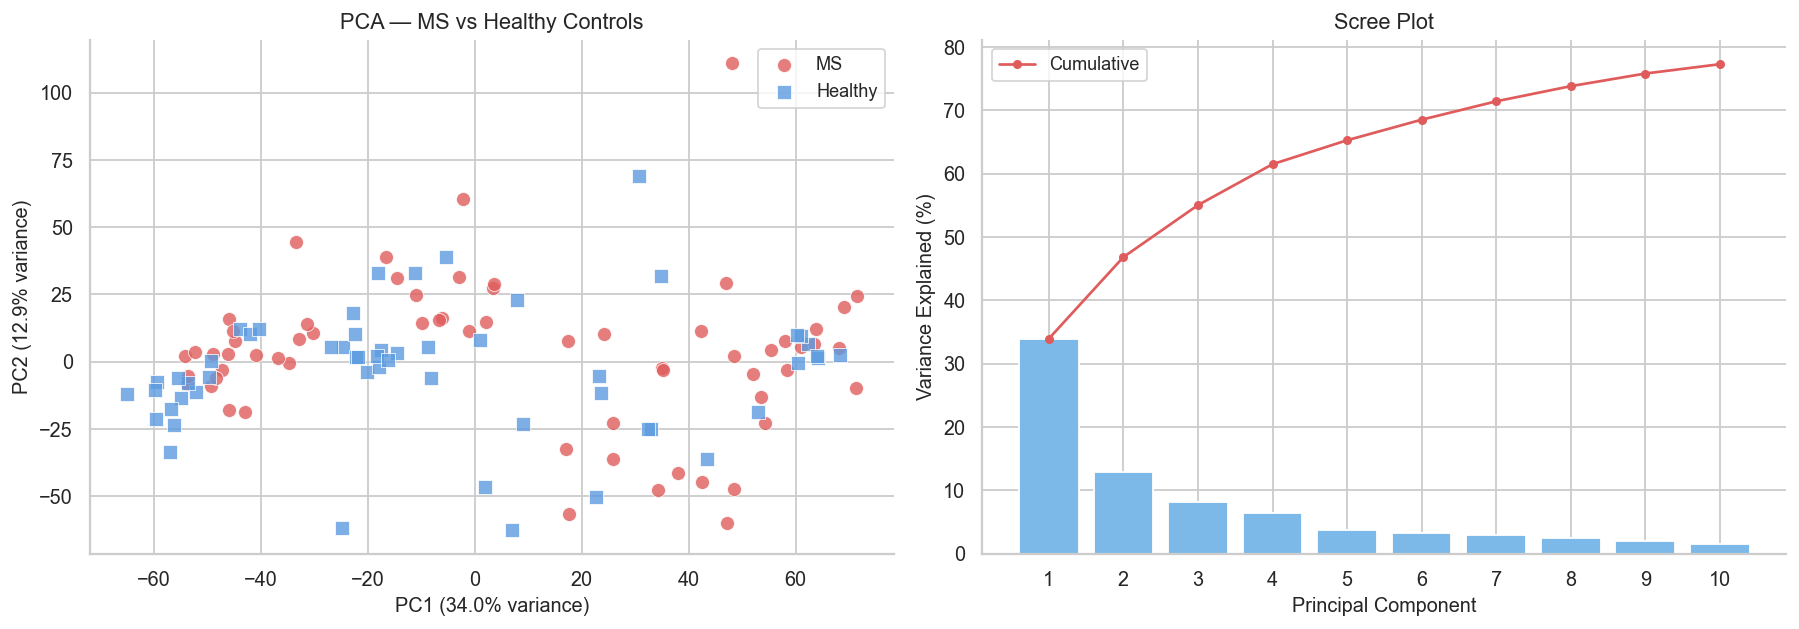

      Saved  → ../outputs/GSE26927\pca.png


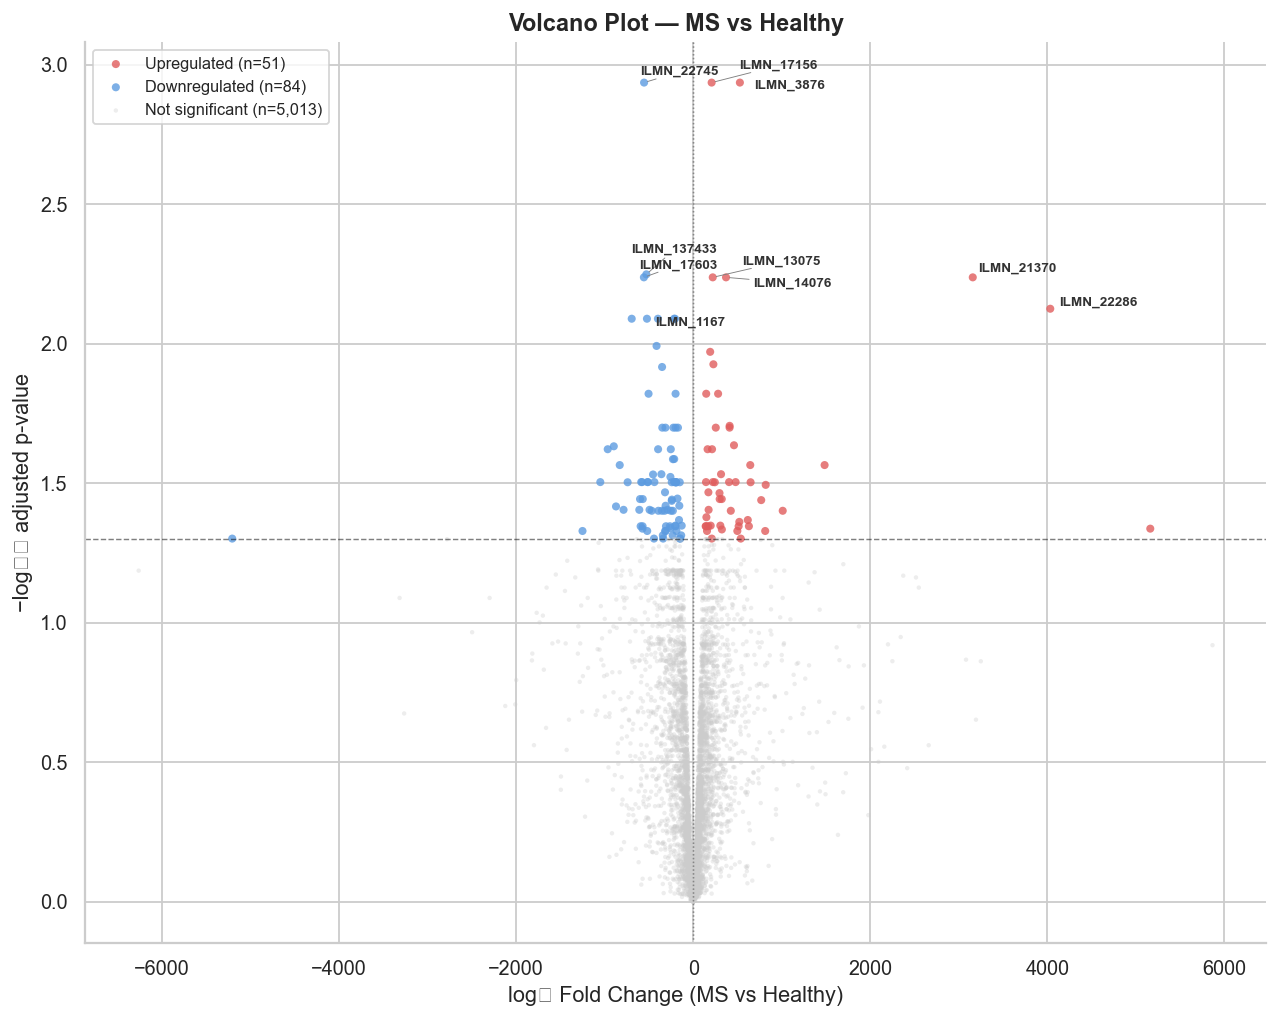

      Saved  → ../outputs/GSE26927\volcano.png


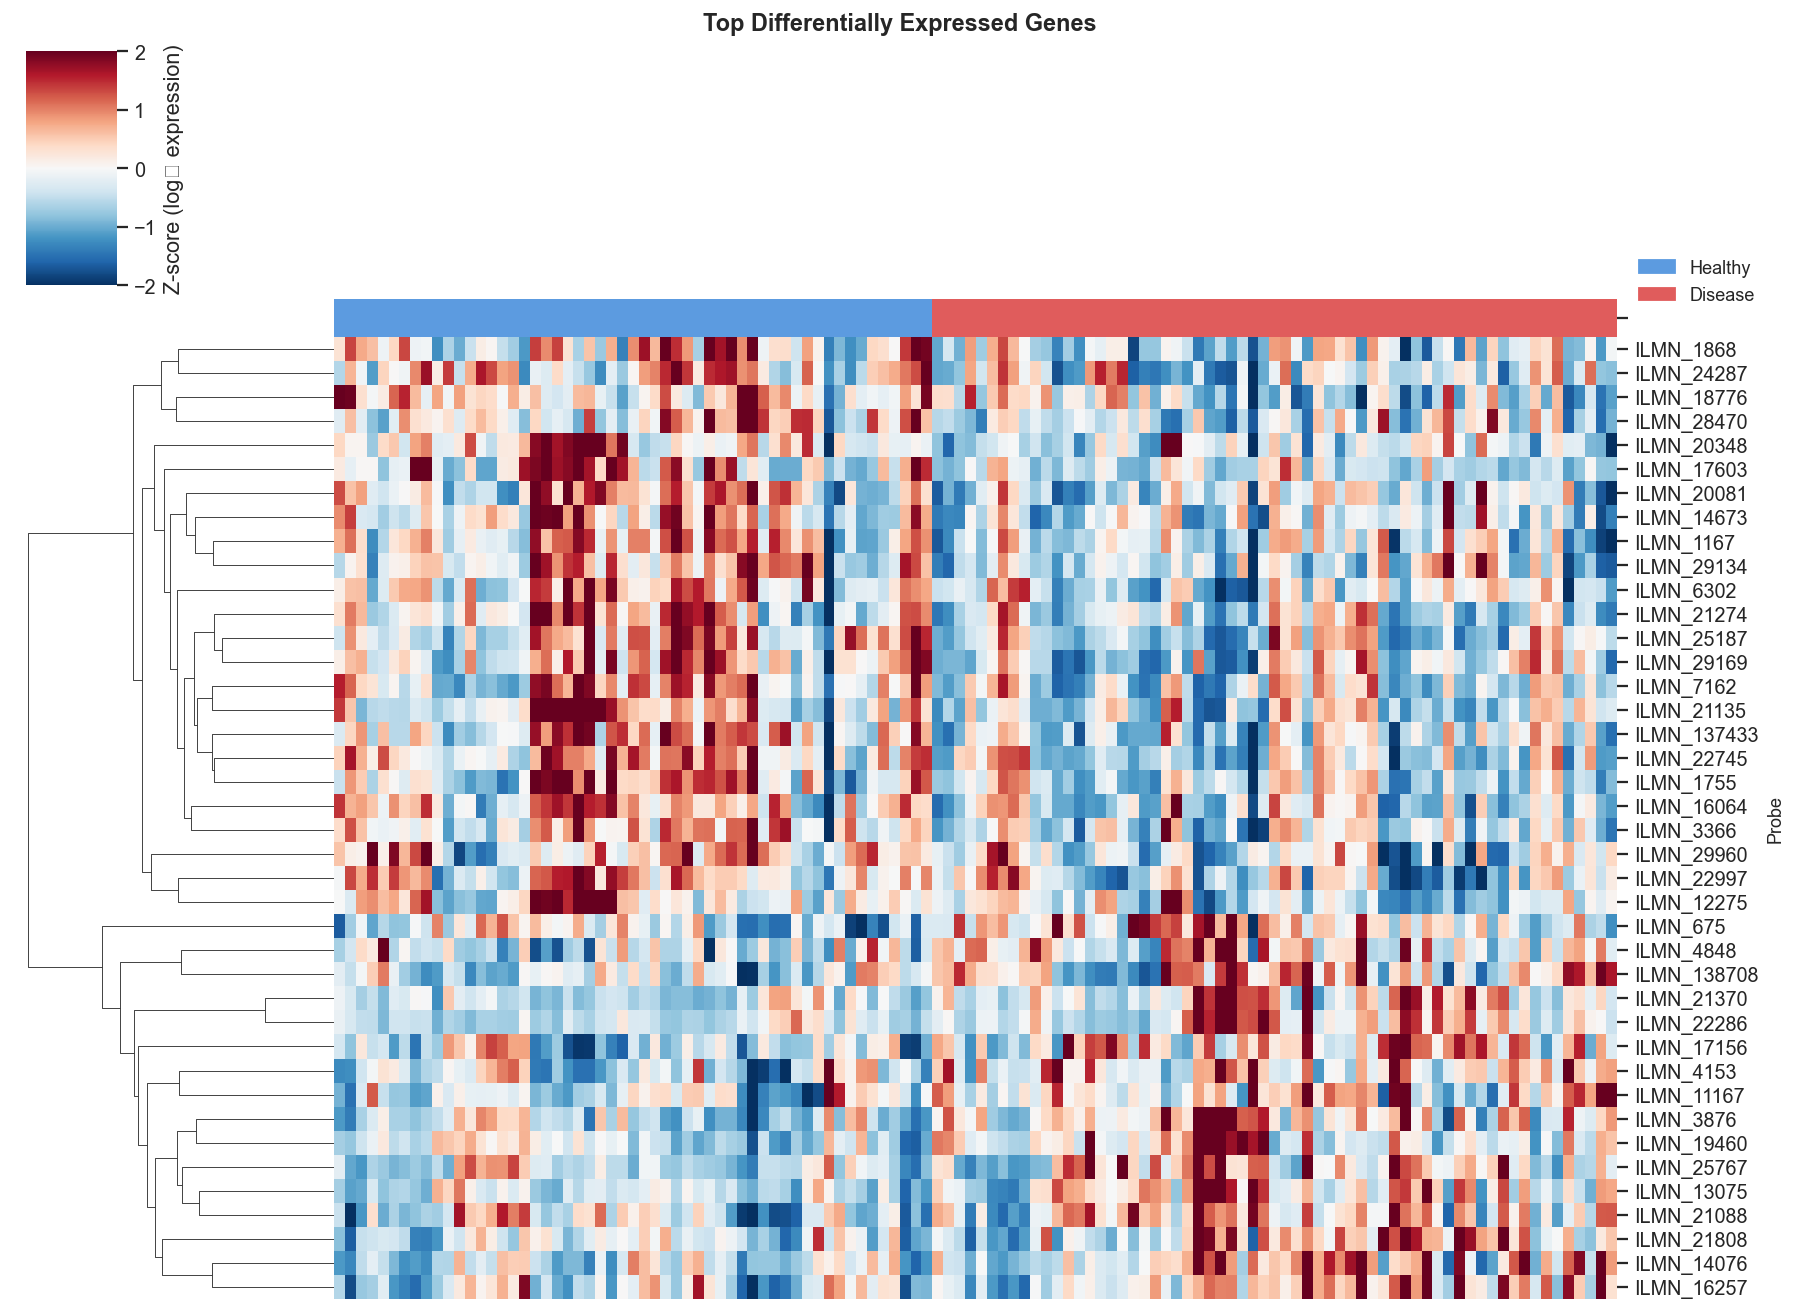

      Saved  → ../outputs/GSE26927\heatmap.png
[5/5] Generating report...

  NEURO-DEG-SCANNER  ·  RESULTS SUMMARY
  Dataset         : GSE26927
  Condition       : MS vs Healthy
  Disease samples : 63
  Healthy samples : 55
  Probes tested   : 5,148
  Upregulated     : 51   (FDR<0.05, log₂FC>0.5)
  Downregulated   : 84   (FDR<0.05, log₂FC<-0.5)

  Top 10 upregulated:
      probe    log2FC   padj
 ILMN_18028 5162.1541 0.0461
 ILMN_22286 4032.6667 0.0075
 ILMN_21370 3157.4444 0.0058
ILMN_137328 1484.2075 0.0273
   ILMN_540 1011.1784 0.0397
 ILMN_12468  819.1364 0.0321
 ILMN_17676  813.5007 0.0470
 ILMN_21748  768.3430 0.0364
 ILMN_28024  648.5299 0.0314
 ILMN_21253  644.6943 0.0273

  Top 10 downregulated:
     probe     log2FC   padj
 ILMN_2789 -5205.3630 0.0500
ILMN_17626 -1249.6829 0.0470
 ILMN_6419 -1048.7588 0.0314
ILMN_20348  -965.0732 0.0239
 ILMN_6302  -896.3259 0.0233
ILMN_10950  -871.3953 0.0383
ILMN_20081  -829.3640 0.0273
ILMN_15268  -786.2057 0.0394
 ILMN_2731  -740.1962 0.0

In [2]:
import sys
sys.path.insert(0, '..')   # point to the repo root

from neuro_deg_scanner import run

results = run(
    geo_id           = 'GSE26927',
    disease_label    = 'MS',
    disease_keywords = ['ms', 'multiple sclerosis', 'rrms', 'patient'],
    healthy_keywords = ['healthy', 'control', 'hc'],
    fdr_threshold    = 0.05,
    lfc_threshold    = 0.5,
    output_dir       = '../outputs/GSE26927',
)

In [3]:
# Explore results
results[results['significance'] != 'Not significant'].sort_values('padj').head(20)

,probe,log2FC,pval,padj,-log10padj,significance
3776,ILMN_22745,-554.358879,6.760473e-07,0.001160,2.935506,Downregulated
2866,ILMN_17156,208.612782,5.475882e-07,0.001160,2.935506,Upregulated
678,ILMN_3876,527.560594,3.663623e-07,0.001160,2.935506,Upregulated
4993,ILMN_137433,-528.877152,4.387731e-06,0.005647,2.248181,Downregulated
3540,ILMN_21370,3157.444400,8.071241e-06,0.005789,2.237427,Upregulated
2232,ILMN_13075,220.995171,6.531883e-06,0.005789,2.237427,Upregulated
2390,ILMN_14076,371.091849,6.815955e-06,0.005789,2.237427,Upregulated
2944,ILMN_17603,-556.523441,8.995479e-06,0.005789,2.237427,Downregulated
3690,ILMN_22286,4032.666747,1.311223e-05,0.007500,2.124927,Upregulated
3137,ILMN_18776,-215.452412,2.149335e-05,0.008145,2.089121,Downregulated
